DBSCAN

In [1]:
#importar cv
import pandas as pd
dataset = pd.read_csv("realestate_data_southcarolina_2025.csv")


In [2]:
dataset.head()

,type,sub_type,sqft,baths,beds,stories,year_built,listPrice
0,condos,condo,1268.0,2.0,3.0,1.0,2002.0,199900.0
1,condos,condo,969.0,2.0,2.0,7.0,1985.0,119900.0
2,single_family,NaN,2181.0,3.0,3.0,2.0,NaN,100000.0
3,single_family,NaN,2083.0,2.0,3.0,NaN,1983.0,309900.0
4,land,NaN,NaN,0.0,NaN,NaN,NaN,1000.0


In [3]:
dataset.describe

<bound method NDFrame.describe of                type sub_type    sqft  baths  beds  stories  year_built  \
0            condos    condo  1268.0    2.0   3.0      1.0      2002.0   
1            condos    condo   969.0    2.0   2.0      7.0      1985.0   
2     single_family      NaN  2181.0    3.0   3.0      2.0         NaN   
3     single_family      NaN  2083.0    2.0   3.0      NaN      1983.0   
4              land      NaN     NaN    0.0   NaN      NaN         NaN   
...             ...      ...     ...    ...   ...      ...         ...   
4996  single_family      NaN  2088.0    3.0   3.0      2.0         NaN   
4997  single_family      NaN  1417.0    2.0   3.0      1.0      2020.0   
4998  single_family      NaN  3656.0    3.0   3.0      2.0      2009.0   
4999  single_family      NaN  1125.0    2.0   4.0      1.0      1972.0   
5000  single_family      NaN  1675.0    2.0   3.0      1.0      2023.0   

      listPrice  
0      199900.0  
1      119900.0  
2      100000.0  
3    

In [4]:
dataset.shape

(5001, 8)

In [5]:
data_dbscan = dataset[['listPrice','sqft']]
data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.0
1,119900.0,969.0
2,100000.0,2181.0
3,309900.0,2083.0
4,1000.0,NaN


In [6]:
data_dbscan['sqft'].isna().sum()

np.int64(804)

Se identificaron 804 valores nulos o no existentes y separa mantener el tamaño del conjuto se ha determinado sustituir

In [7]:
cleaned_data_dbscan = data_dbscan.dropna(subset=['sqft'])

In [8]:
cleaned_data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.0
1,119900.0,969.0
2,100000.0,2181.0
3,309900.0,2083.0
8,63000.0,1200.0


In [9]:
cleaned_data_dbscan.shape

(4197, 2)

In [10]:
#Promedio del tamaño de las propiedades
sqft_mean = data_dbscan['sqft'].mean()
data_dbscan['sqft'] = data_dbscan['sqft'].fillna(sqft_mean)
data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.000000
1,119900.0,969.000000
2,100000.0,2181.000000
3,309900.0,2083.000000
4,1000.0,1997.527043


In [11]:
data_dbscan['listPrice'].isna().sum()

np.int64(28)

In [12]:
#Promedio del tamaño de las propiedades
sqft_mean = data_dbscan['listPrice'].mean()
data_dbscan['listPrice'] = data_dbscan['listPrice'].fillna(sqft_mean)
data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.000000
1,119900.0,969.000000
2,100000.0,2181.000000
3,309900.0,2083.000000
4,1000.0,1997.527043


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_dbscan)
data_scaled

array([[-0.32933367, -0.72477857],
       [-0.42622553, -1.02183239],
       [-0.45032738,  0.18227874],
       ...,
       [ 0.34890934,  1.647678  ],
       [-0.37765848, -0.86684779],
       [-0.15662393, -0.32042772]], shape=(5001, 2))

In [14]:
#Parametros iniciales
import numpy as np
dbscan = DBSCAN(eps=0.5,min_samples=5)

#Determinación de clusteres
clusters = dbscan.fit(data_scaled)
np.unique(clusters.labels_)

array([-1,  0,  1,  2])

In [15]:
dataset_clustered = data_dbscan.copy()
dataset_clustered['cluster'] = clusters.labels_
dataset_clustered.head()

,listPrice,sqft,cluster
0,199900.0,1268.000000,0
1,119900.0,969.000000,0
2,100000.0,2181.000000,0
3,309900.0,2083.000000,0
4,1000.0,1997.527043,0


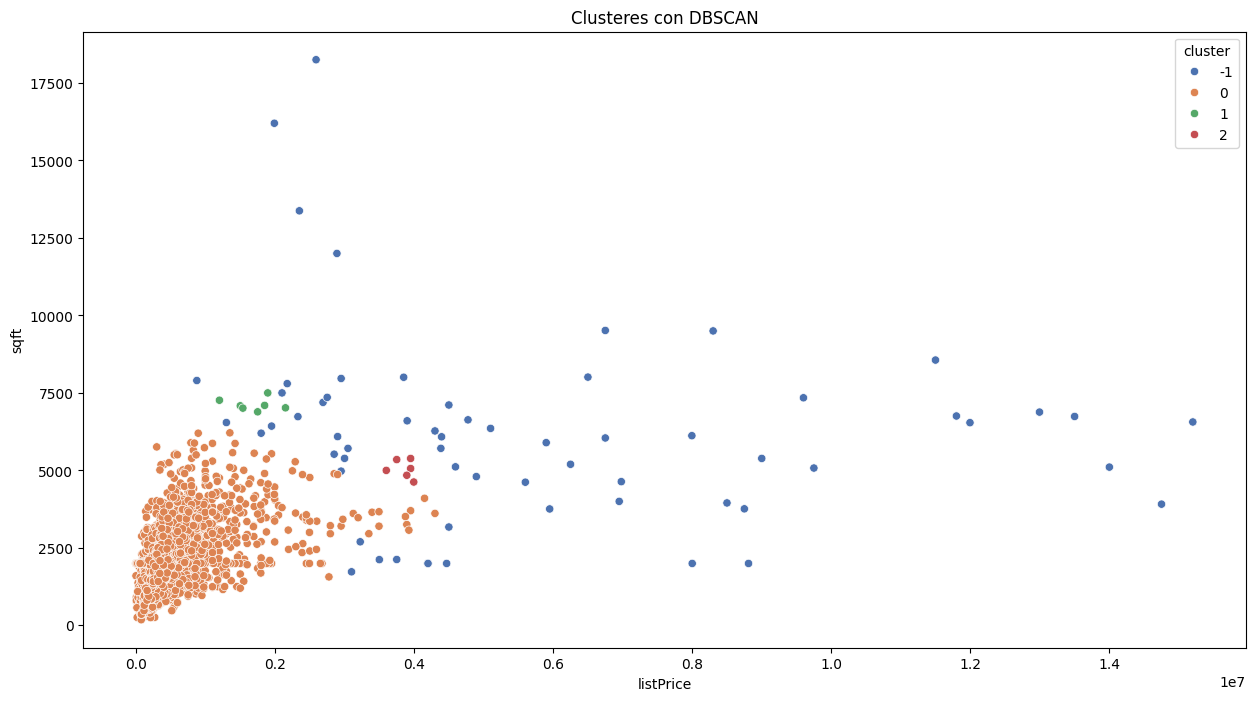

In [16]:
#Graficcacion del conjunto de datos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.scatterplot(x='listPrice',y='sqft',hue='cluster',data=dataset_clustered,palette='deep')
plt.title('Clusteres con DBSCAN')
plt.xlabel = 'Precio de lista'
plt.ylabel = 'Tamaño de la propiedad'
plt.grid = True
plt.show()